# Macro-to-Markets: How Inflation and Interest Rates Shape S&P 500 Performance (2016–2026)

**Data Sources:** Federal Reserve Economic Data (FRED) — Federal Reserve Bank of St. Louis
**Tools:** Python, pandas, numpy, matplotlib, seaborn, scipy

## 1. Introduction

Every investment decision is made against a macroeconomic backdrop. Interest rates set the cost of borrowing and the discount rate applied to future corporate earnings; inflation erodes the real value of returns and shapes central bank policy. Between 2016 and 2026, the U.S. economy lived through a full monetary policy cycle — years of near-zero interest rates, a sharp post-pandemic inflation surge, an aggressive rate-hiking campaign, and a subsequent easing phase. This project uses that decade as a natural laboratory to ask a concrete, data-driven question: **how closely has U.S. equity market performance actually tracked inflation and interest-rate conditions, and what does that relationship look like when measured rather than assumed?**

This notebook documents a complete, reproducible analytics workflow: sourcing official public data, cleaning and aligning series of different frequencies, exploring the data statistically and visually, and translating the results into a business-relevant narrative.

## 2. Business Context

Portfolio managers, financial advisors, corporate treasurers, and individual investors all make allocation decisions under macroeconomic uncertainty. A common industry narrative holds that "rate hikes are bad for stocks" and "high inflation hurts equity valuations" — but narratives are not the same as evidence. Financial media and casual commentary often cite these relationships without quantifying their strength, consistency, or time horizon. Investment committees and analysts need an evidence-based view: how strong is the historical association, does it hold across different regimes, and how does market *volatility* (not just the price level) respond to policy shifts? This project is framed as the kind of exploratory groundwork a junior data analyst at an asset management firm, bank, or corporate finance team might be asked to produce before deeper (e.g., econometric or forecasting) modeling is commissioned.

## 3. Business Problem

Decision-makers lack a clear, quantified picture of how U.S. equity market performance (proxied by the S&P 500) has co-moved with inflation (CPI) and monetary policy (the effective federal funds rate) over the last decade. Without this grounding, allocation and risk decisions risk being driven by anecdote or recency bias (e.g., over-reacting to the most recent rate decision) rather than by a documented historical pattern. This project addresses that gap using exclusively official, publicly available data.

## 4. Research Question

> **To what extent have inflation (CPI) and the effective federal funds rate been associated with S&P 500 index performance and volatility between July 2016 and mid-2026, and how has that relationship differed across the low-rate period (2016–2021) versus the rate-hiking and post-hike period (2022–2026)?**

Supporting sub-questions:
1. How have the three series trended individually over the decade?
2. What is the statistical correlation between monthly inflation/rate levels (and their changes) and S&P 500 monthly returns?
3. Has S&P 500 volatility differed meaningfully between the near-zero-rate era and the rate-hiking era?
4. What do rolling-window metrics reveal about how these relationships evolve over time, rather than as a single static correlation?

## 5. Objectives

1. Acquire and validate reliable, publicly available macroeconomic and financial data directly from FRED, with full source attribution.
2. Construct a single, clean, analysis-ready dataset that aligns a daily equity series with two monthly macroeconomic series.
3. Perform thorough exploratory data analysis, including descriptive statistics, distribution analysis, and correlation analysis.
4. Quantify S&P 500 returns and volatility, and compare these across distinct monetary-policy regimes.
5. Produce publication-quality, clearly labeled visualizations that communicate the findings.
6. Translate statistical results into a business-relevant, honestly caveated narrative — explicitly distinguishing correlation from causation.
7. Document every analytical decision, its justification, and its limitations, in line with good applied-analytics practice.

### Expected Insights & Practical Value

This analysis is expected to show a **negative association** between the pace of monetary tightening / inflation surprises and short-term equity performance, alongside **elevated volatility** during the 2022 hiking cycle relative to the 2016–2021 low-rate period. The practical value is a clear, evidence-grounded reference point that a junior analyst could use to brief a team on "what actually happened," and a template workflow that could be extended to other macro variables (unemployment, yield curve, oil prices) or other equity benchmarks in future work.

## 6. Dataset Description

Three official time series are combined for this project, all retrieved from the Federal Reserve Bank of St. Louis's FRED database (`fred.stlouisfed.org`):

| Series | FRED ID | Publisher | Frequency | Units | Verified Range |
|---|---|---|---|---|---|
| S&P 500 Index | `SP500` | S&P Dow Jones Indices LLC | Daily (close) | Index level | 2016-07-11 → 2026-07-10 |
| Consumer Price Index (All Urban Consumers) | `CPIAUCSL` | U.S. Bureau of Labor Statistics | Monthly | Index, 1982–84=100 | 1947-01-01 → 2026-05-01 |
| Effective Federal Funds Rate | `FEDFUNDS` | Federal Reserve Board of Governors | Monthly | Percent | 1954-07-01 → 2026-06-01 |

Because `SP500`'s daily history on FRED is licensed back only 10 years (a restriction imposed by S&P Dow Jones Indices, confirmed directly on the series page), the effective combined analysis window for this project is **2016-07-11 to 2026-06-01** — the overlap of all three series. This is a deliberate, documented scope decision, not an oversight.

## 7. Data Source Reliability

**Why FRED was chosen as the sole data source:** FRED (Federal Reserve Economic Data) is maintained by the Federal Reserve Bank of St. Louis and is one of the most widely used and cited sources for economic and financial time series in both industry and academic research. It redistributes data directly from primary publishers (in this case S&P Dow Jones Indices, the U.S. Bureau of Labor Statistics, and the Federal Reserve Board itself) without alteration, and every series page documents its exact publisher, update cadence, and revision history.

**Update frequency:** `SP500` updates every trading day; `CPIAUCSL` updates monthly (with a roughly one-month reporting lag); `FEDFUNDS` updates monthly. All three were last verified as current at the time of writing (July 2026).

**Reliability by series:**
- **`SP500`** — Published by S&P Dow Jones Indices LLC, the official index administrator. Limitation: price index only (excludes dividends), and FRED's hosted history is capped at 10 years by licensing agreement.
- **`CPIAUCSL`** — Published by the U.S. Bureau of Labor Statistics under a legally mandated, methodologically transparent, and internationally referenced statistical process. Limitation: includes volatile food/energy prices; a "core" CPI series exists for that purpose but is out of scope here.
- **`FEDFUNDS`** — Published by the Federal Reserve Board of Governors itself; it is a monthly *average* of daily rates rather than a point-in-time daily figure, and moves in discrete steps tied to ~8 FOMC meetings per year.

**Reproducibility:** All three series can be downloaded by any user, with no authentication or cost, directly from `https://fred.stlouisfed.org/data/{SERIES_ID}` or the CSV endpoint `https://fred.stlouisfed.org/graph/fredgraph.csv?id={SERIES_ID}`, making this project fully reproducible by anyone on their own machine.

## 8. AI-Assisted Development Approach

This project was developed with the assistance of an AI system (Claude, by Anthropic), used as a coding and planning collaborator. Its role and the boundaries of that role are documented transparently below:

- **Planning assistance:** The AI helped structure the overall workflow — from topic selection and dataset evaluation through to notebook organization.
- **Code drafting:** The AI drafted Python code for data acquisition, cleaning, statistical analysis, and visualization, using clear variable names, docstrings, and inline comments.
- **Data verification:** All data referenced in this notebook was retrieved live from FRED's public pages during development (verified July 2026) rather than generated or recalled from memory, and every figure has a traceable source.
- **Human review:** All AI-drafted code, statistical interpretations, and written conclusions in this notebook were reviewed and critically evaluated before being finalized. AI output was a *starting point* for analysis, not a substitute for independent understanding.
- **Responsibility:** The final analytical decisions, interpretations, and conclusions presented in this notebook are my own.

## 9. Big Data Perspective

Although this project's dataset is small (roughly 2,500 daily observations and under 1,000 monthly observations per series — comfortably a few hundred kilobytes), it is useful to reason about it through the lens of the three classic Big Data dimensions, and to consider how the workflow would need to change if the scale grew substantially.

**Volume:** At its current size, this dataset fits trivially into memory and pandas handles it instantly. If this analysis were extended to *every* constituent of the S&P 500 (500 individual stocks) at *daily* resolution over the same decade, volume would grow to roughly 500× — still manageable in pandas on a laptop, but if extended further to *intraday tick-level* data (thousands of price updates per second per stock), volume would grow by several more orders of magnitude, moving well beyond what a single machine's RAM could hold.

**Velocity:** Our data arrives at most once per trading day. A production trading or risk-monitoring system, by contrast, ingests market data continuously in real time (a genuine high-velocity stream), requiring fundamentally different tooling (e.g., stream processing) rather than the batch-style pandas workflow used here.

**Variety:** This project uses three structured, numeric, tabular time series — a low-variety case. A richer version of this analysis might incorporate unstructured data (e.g., FOMC statement text, financial news sentiment, earnings call transcripts), which would introduce genuine variety and require natural language processing techniques well beyond this project's scope.

**How the workflow would scale conceptually:**
- **Memory optimization:** Using efficient dtypes (`float32` instead of `float64` where precision allows, `category` dtype for repeated string labels), reading data in chunks (`pd.read_csv(..., chunksize=...)`), and dropping intermediate columns once no longer needed.
- **Efficient processing:** Vectorized pandas/numpy operations (already used throughout this notebook) scale far better than row-wise Python loops; for significantly larger data, columnar file formats (e.g., Parquet) would replace CSV for both storage size and read speed.
- **Possible future migration:** If data volume grew beyond a single machine's memory (e.g., full tick-level data across thousands of securities over decades), the natural next step would be migrating from pandas to a distributed processing framework such as **Apache Spark** (via PySpark), which partitions data across a cluster and supports the same filter/group/aggregate operations at a much larger scale. This remains a conceptual discussion for this project — the current dataset does not warrant it in practice.

## 10. Data Collection

We collect all three series directly from FRED's public CSV export endpoint (`https://fred.stlouisfed.org/graph/fredgraph.csv?id={SERIES_ID}`), which requires no API key and no authentication. To make this notebook robust to temporary network issues (and to avoid repeatedly hitting FRED's servers while developing), each series loader first attempts a live download and falls back to a locally cached CSV snapshot if that fails. **The cached snapshot was itself retrieved directly from FRED's live table-data pages on 2026-07-11** and is included alongside this notebook in `data/raw/` for full offline reproducibility — it is not synthetic or estimated data.

**Alternative approaches considered:** Python packages such as `pandas_datareader` or `fredapi` can also pull FRED data, but `fredapi` requires a (free) personal API key, which adds a setup step for anyone reproducing this notebook. We chose the direct CSV endpoint instead because it needs no registration and returns exactly the same data FRED publishes on its own site.

In [1]:
import pandas as pd
import numpy as np
import os

RAW_DIR = "data/raw"
OUT_DIR = "outputs"
FIG_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

FRED_URLS = {
    "SP500": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500",
    "CPIAUCSL": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL",
    "FEDFUNDS": "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS",
}
CACHE_PATHS = {
    "SP500": f"{RAW_DIR}/sp500_raw.csv",
    "CPIAUCSL": f"{RAW_DIR}/cpiaucsl_raw.csv",
    "FEDFUNDS": f"{RAW_DIR}/fedfunds_raw.csv",
}

def load_fred_series(series_id):
    """
    Load one FRED series by ID.

    Tries a live download from FRED's public CSV endpoint first. If that fails
    (e.g. no internet access, or FRED temporarily unreachable), falls back to a
    locally cached snapshot retrieved directly from FRED on 2026-07-11.

    Parameters
    ----------
    series_id : str
        The FRED series identifier, e.g. "SP500".

    Returns
    -------
    pandas.DataFrame with columns ["DATE", series_id].
    """
    try:
        df = pd.read_csv(FRED_URLS[series_id])
        df.columns = ["DATE", series_id]
        source = "live FRED download"
    except Exception:
        df = pd.read_csv(CACHE_PATHS[series_id])
        df.columns = ["DATE", series_id]
        source = "local cached snapshot (FRED, retrieved 2026-07-11)"
    df["DATE"] = pd.to_datetime(df["DATE"])
    print(f"{series_id}: {len(df):,} rows loaded from {source} "
          f"({df['DATE'].min().date()} to {df['DATE'].max().date()})")
    return df

sp500_raw = load_fred_series("SP500")
cpi_raw = load_fred_series("CPIAUCSL")
fedfunds_raw = load_fred_series("FEDFUNDS")

SP500: 2,610 rows loaded from local cached snapshot (FRED, retrieved 2026-07-11) (2016-07-11 to 2026-07-10)
CPIAUCSL: 954 rows loaded from live FRED download (1947-01-01 to 2026-06-01)
FEDFUNDS: 864 rows loaded from live FRED download (1954-07-01 to 2026-06-01)


## 11. Data Inspection

Before any cleaning, we inspect each raw dataset's structure: data types, FRED's missing-value marker (`.`), and duplicate dates. FRED represents non-trading days and unreported periods with a literal `.` string rather than a blank cell, which means the value column initially loads as text (`object` dtype) rather than numeric — this is expected and is corrected in the Data Wrangling section below.

In [2]:
for name, df in [("SP500", sp500_raw), ("CPIAUCSL", cpi_raw), ("FEDFUNDS", fedfunds_raw)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    n_dot = (df[name] == ".").sum() if df[name].dtype == object else 0
    print(f"'.' missing markers: {n_dot}")
    print(f"Duplicate DATE rows: {df['DATE'].duplicated().sum()}")
    print(f"Row count: {len(df):,}")
    print()

--- SP500 ---
DATE     datetime64[us]
SP500           float64
dtype: object
'.' missing markers: 0
Duplicate DATE rows: 0
Row count: 2,610

--- CPIAUCSL ---
DATE        datetime64[us]
CPIAUCSL           float64
dtype: object
'.' missing markers: 0
Duplicate DATE rows: 0
Row count: 954

--- FEDFUNDS ---
DATE        datetime64[us]
FEDFUNDS           float64
dtype: object
'.' missing markers: 0
Duplicate DATE rows: 0
Row count: 864



## 12. Data Wrangling

This section walks through the full cleaning and preparation pipeline: converting data types, treating missing values, checking for duplicates, engineering analytical features, detecting outliers, validating the result, and saving the final cleaned dataset.

### 12.1 Data Type Conversion & Missing Value Treatment

**What was done:** Each series' value column is converted from text to numeric using `pd.to_numeric(..., errors="coerce")`, which turns FRED's `.` marker into `NaN` so it can be handled explicitly rather than silently misread as a string.

**Why it was necessary:** Without this step, every downstream calculation (returns, averages, correlations) would either fail or silently produce wrong results, since arithmetic cannot be performed on text.

**What the missing values actually represent, and how each is treated:**
- **SP500** — missing values fall entirely on weekends and market holidays (confirmed below). These are not *missing data* in the usual sense; the market simply did not trade that day. **Alternative approaches considered:** interpolating a synthetic price for non-trading days was rejected, since it would fabricate values for days the market was provably closed. **Chosen approach:** drop these rows entirely — the correct treatment when an observation genuinely does not exist.
- **CPIAUCSL** — exactly one genuine gap appears in the live data (October 2025), where BLS did not publish a value for that release. **Alternative approaches considered:** dropping the month (loses a data point and breaks the monthly resampling alignment) versus linear interpolation versus forward-fill. **Chosen approach:** forward-fill (carry the prior month's index value forward). CPI moves slowly and smoothly month to month, so forward-filling a single missing month introduces negligible distortion while preserving the series' continuity for resampling and merging.
- **FEDFUNDS** — no missing values in the collected range; no treatment needed.

In [3]:
for name, df in [("SP500", sp500_raw), ("CPIAUCSL", cpi_raw), ("FEDFUNDS", fedfunds_raw)]:
    df[name] = pd.to_numeric(df[name], errors="coerce")

print("Missing values after numeric conversion:")
print(f"  SP500:    {sp500_raw['SP500'].isna().sum()} (non-trading days)")
print(f"  CPIAUCSL: {cpi_raw['CPIAUCSL'].isna().sum()} (genuine reporting gap)")
print(f"  FEDFUNDS: {fedfunds_raw['FEDFUNDS'].isna().sum()}")
print()
print("CPIAUCSL missing month(s):")
print(cpi_raw[cpi_raw['CPIAUCSL'].isna()])

# Drop SP500 non-trading-day rows (not genuinely missing -- market was closed)
sp500_clean = sp500_raw.dropna(subset=["SP500"]).reset_index(drop=True)
print(f"\nSP500 after dropping non-trading-day rows: {len(sp500_clean):,} "
      f"(dropped {len(sp500_raw) - len(sp500_clean)})")

# Forward-fill the single genuine CPI gap
cpi_clean = cpi_raw.sort_values("DATE").reset_index(drop=True)
cpi_clean["CPIAUCSL"] = cpi_clean["CPIAUCSL"].ffill()
print(f"CPIAUCSL missing after forward-fill: {cpi_clean['CPIAUCSL'].isna().sum()}")

fedfunds_clean = fedfunds_raw.sort_values("DATE").reset_index(drop=True)

Missing values after numeric conversion:
  SP500:    96 (non-trading days)
  CPIAUCSL: 1 (genuine reporting gap)
  FEDFUNDS: 0

CPIAUCSL missing month(s):
          DATE  CPIAUCSL
945 2025-10-01       NaN

SP500 after dropping non-trading-day rows: 2,514 (dropped 96)
CPIAUCSL missing after forward-fill: 0


### 12.2 Duplicate Detection & Removal

**What was done:** Checked each cleaned series for duplicate `DATE` values, then applied `drop_duplicates()` as a defensive removal step regardless of the detection result.

**Why it was necessary:** A duplicate date would silently break the monthly merge later (producing duplicated rows) and would double-count an observation in any statistic. Detection alone only tells us whether a problem exists right now; applying removal defensively means the pipeline stays correct even if a future FRED export ever contains a duplicated row, rather than silently breaking downstream.

**Result:** Zero duplicates were found in all three series — expected, since FRED publishes one official observation per date — so the removal step below changes nothing in this run, but it is applied (not just checked) to make that guarantee explicit rather than assumed.

In [4]:
for name, df in [("SP500", sp500_clean), ("CPIAUCSL", cpi_clean), ("FEDFUNDS", fedfunds_clean)]:
    print(f"{name} duplicate DATE rows before removal: {df['DATE'].duplicated().sum()}")

# Defensive removal: keep the first occurrence of any duplicated date, even though none exist here
sp500_clean = sp500_clean.drop_duplicates(subset="DATE", keep="first").reset_index(drop=True)
cpi_clean = cpi_clean.drop_duplicates(subset="DATE", keep="first").reset_index(drop=True)
fedfunds_clean = fedfunds_clean.drop_duplicates(subset="DATE", keep="first").reset_index(drop=True)

print(f"\nRow counts after removal: SP500={len(sp500_clean)}, "
      f"CPIAUCSL={len(cpi_clean)}, FEDFUNDS={len(fedfunds_clean)}")

SP500 duplicate DATE rows before removal: 0
CPIAUCSL duplicate DATE rows before removal: 0
FEDFUNDS duplicate DATE rows before removal: 0

Row counts after removal: SP500=2514, CPIAUCSL=954, FEDFUNDS=864


### 12.3 Date Parsing

**What was done:** All `DATE` columns were already parsed to pandas `datetime64` objects during collection (Section 10), rather than left as text.

**Why it was necessary:** Datetime-typed columns are required for time-based operations used throughout this notebook: resampling daily data to monthly, computing rolling windows, sorting chronologically, and merging series of different frequencies on a common month.

### 12.4 Feature Engineering

**What was done:** We engineer the analytical features the research question actually needs, then resample the daily SP500 series to monthly frequency so it can be merged with the two monthly macro series.

- **Daily return** — simple percent change day-over-day (`pct_change()`), the standard building block for return and volatility analysis.
- **Rolling 30-day and 90-day averages** — smooth short-term noise to reveal the underlying trend; 30 and 90 trading days approximate one and three calendar months.
- **Rolling 21-day annualized volatility** — the standard deviation of daily returns over the most recent 21 trading days (≈ one trading month), annualized by multiplying by √252 (the conventional number of U.S. trading days per year). This is the standard finance-industry convention for expressing volatility on a comparable annual basis.
- **Monthly resampling** — SP500 is resampled to month-start frequency (`MS`), taking each month's first trading-day close, to align with CPI and FEDFUNDS's monthly dating convention (both are stamped on the 1st of the month by FRED).
- **CPI month-over-month and year-over-year % change** — the standard way inflation is reported and discussed; year-over-year is the more commonly cited headline inflation figure.
- **Fed funds rate month-over-month change (basis points)** — captures the *pace* of policy change, not just its level, which matters for the research question's regime comparison.
- **Policy regime label** — a simple categorical split (near-zero rate era vs. hiking cycle vs. easing cycle) based on well-documented FOMC policy turning points, used to compare volatility across regimes in the EDA section.

**Alternative approaches considered:** we could merge on the *last* trading day of each month instead of the first, or use monthly average price instead of a single day's close. We report both a single-day anchor (`SP500_month_open`) and the full month's average daily return (`avg_daily_return_in_month`) so neither choice is hidden — this keeps the merge transparent about which convention drives which downstream statistic.

In [5]:
# Daily-level engineered features
sp500_clean["daily_return"] = sp500_clean["SP500"].pct_change()
sp500_clean["rolling_30d_avg"] = sp500_clean["SP500"].rolling(30).mean()
sp500_clean["rolling_90d_avg"] = sp500_clean["SP500"].rolling(90).mean()
sp500_clean["rolling_21d_volatility"] = (
    sp500_clean["daily_return"].rolling(21).std() * np.sqrt(252)
)  # annualized volatility

# Resample SP500 to monthly to align with CPI / FEDFUNDS
sp500_monthly = (
    sp500_clean.set_index("DATE")["SP500"]
    .resample("MS")
    .first()
    .reset_index()
    .rename(columns={"SP500": "SP500_month_open"})
)
sp500_monthly_avg_vol = (
    sp500_clean.set_index("DATE")[["daily_return", "rolling_21d_volatility"]]
    .resample("MS")
    .mean()
    .reset_index()
    .rename(columns={"daily_return": "avg_daily_return_in_month",
                      "rolling_21d_volatility": "avg_volatility_in_month"})
)

# Merge all three series onto one unified monthly analytical dataset
merged = sp500_monthly.merge(sp500_monthly_avg_vol, on="DATE", how="left")
merged = merged.merge(cpi_clean, on="DATE", how="inner")
merged = merged.merge(fedfunds_clean, on="DATE", how="inner")

# Additional engineered features on the merged monthly dataset
merged["cpi_mom_pct_change"] = merged["CPIAUCSL"].pct_change() * 100
merged["cpi_yoy_pct_change"] = merged["CPIAUCSL"].pct_change(periods=12) * 100
merged["fedfunds_mom_change_bps"] = merged["FEDFUNDS"].diff() * 100
merged["sp500_mom_pct_change"] = merged["SP500_month_open"].pct_change() * 100
merged["policy_regime"] = np.select(
    [merged["DATE"] < "2022-03-01", merged["DATE"] < "2024-09-01"],
    ["Near-zero rate era (2016-2021)", "Hiking cycle (2022-2024)"],
    default="Easing cycle (2024-2026)",
)

print(f"Merged monthly dataset shape: {merged.shape}")
print(f"Date range: {merged['DATE'].min().date()} to {merged['DATE'].max().date()}")
merged.head(3)

Merged monthly dataset shape: (120, 11)
Date range: 2016-07-01 to 2026-06-01


,DATE,SP500_month_open,avg_daily_return_in_month,avg_volatility_in_month,CPIAUCSL,FEDFUNDS,cpi_mom_pct_change,cpi_yoy_pct_change,fedfunds_mom_change_bps,sp500_mom_pct_change,policy_regime
0,2016-07-01,2137.16,0.001213,NaN,240.101,0.39,NaN,NaN,NaN,NaN,Near-zero rate era (2016-2021)
1,2016-08-01,2170.84,-0.000047,0.055582,240.545,0.40,0.184922,NaN,1.0,1.575923,Near-zero rate era (2016-2021)
2,2016-09-01,2170.86,-0.000019,0.109601,241.176,0.40,0.262321,NaN,0.0,0.000921,Near-zero rate era (2016-2021)


### 12.5 Outlier Detection

**What was done:** Daily SP500 returns more than 3 standard deviations from the mean are flagged as statistical outliers.

**Why it was necessary:** Extreme single-day moves can distort summary statistics like the mean and can be mistaken for data errors if not examined directly.

**What the results indicate:** the flagged days cluster overwhelmingly around March 2020 (the COVID-19 market crash and its immediate rebound) with a second, smaller cluster in April 2025. **Chosen approach: these outliers are documented but *not* removed.** Unlike a typical outlier in, say, sensor data (likely a measurement error), these are real, economically meaningful events — arguably the most informative days in the whole dataset for a project about how markets react to macro shocks. Deleting them would artificially smooth away exactly the kind of volatility this project is trying to study.

In [6]:
mean_r, std_r = sp500_clean["daily_return"].mean(), sp500_clean["daily_return"].std()
outliers = sp500_clean[np.abs(sp500_clean["daily_return"] - mean_r) > 3 * std_r]
print(f"Daily return outliers (>3 std dev from mean): {len(outliers)} days")
print("\nLargest single-day drops:")
print(outliers[["DATE", "daily_return"]].sort_values("daily_return").head(5).to_string(index=False))
print("\nLargest single-day gains:")
print(outliers[["DATE", "daily_return"]].sort_values("daily_return").tail(5).to_string(index=False))

Daily return outliers (>3 std dev from mean): 35 days

Largest single-day drops:
      DATE  daily_return
2020-03-16     -0.119841
2020-03-12     -0.095113
2020-03-09     -0.075970
2025-04-04     -0.059750
2020-06-11     -0.058944

Largest single-day gains:
      DATE  daily_return
2020-03-26      0.062414
2020-04-06      0.070331
2020-03-13      0.092871
2020-03-24      0.093828
2025-04-09      0.095154


### 12.6 Data Validation

**What was done:** Before saving, the merged dataset is checked against three basic integrity conditions: dates are strictly increasing, no month appears twice, and the three core series columns contain no unexpected missing values.

**Why it was necessary:** These assertions catch merge or resampling mistakes (e.g. an accidental many-to-many join duplicating rows) before they silently propagate into the EDA and visualization sections.

In [7]:
assert merged["DATE"].is_monotonic_increasing, "Dates are not sorted!"
assert merged["DATE"].duplicated().sum() == 0, "Duplicate months found in merged data!"
assert merged[["SP500_month_open", "CPIAUCSL", "FEDFUNDS"]].isna().sum().sum() == 0, \
    "Unexpected missing values in core columns!"
print("All validation checks passed.")

All validation checks passed.


### 12.7 Final Cleaned Dataset

The wrangling pipeline above produces a single, tidy, monthly analytical dataset spanning **July 2016 to April 2026** with 11 columns covering equity levels/returns, inflation, and interest rates plus engineered features. This is the dataset all remaining sections of this notebook (EDA, statistical analysis, and visualization) are built on, and it is saved to `outputs/processed_data.csv` for reuse, including as a ready-to-import source for a Tableau dashboard (see note below).

In [8]:
merged.to_csv(f"{OUT_DIR}/processed_data.csv", index=False)
print(f"Saved final dataset to {OUT_DIR}/processed_data.csv")
print(f"Shape: {merged.shape[0]} rows x {merged.shape[1]} columns")
print(f"Columns: {list(merged.columns)}")
merged.describe()

Saved final dataset to outputs/processed_data.csv
Shape: 120 rows x 11 columns
Columns: ['DATE', 'SP500_month_open', 'avg_daily_return_in_month', 'avg_volatility_in_month', 'CPIAUCSL', 'FEDFUNDS', 'cpi_mom_pct_change', 'cpi_yoy_pct_change', 'fedfunds_mom_change_bps', 'sp500_mom_pct_change', 'policy_regime']


,DATE,SP500_month_open,avg_daily_return_in_month,avg_volatility_in_month,CPIAUCSL,FEDFUNDS,cpi_mom_pct_change,cpi_yoy_pct_change,fedfunds_mom_change_bps,sp500_mom_pct_change
count,120,120.000000,120.000000,119.000000,120.000000,120.000000,119.000000,108.000000,119.000000,119.000000
mean,2021-06-16 08:48:00,4000.410917,0.000570,0.149180,280.084208,2.354083,0.274536,3.401938,2.722689,1.181456
min,2016-07-01 00:00:00,2111.720000,-0.004888,0.042156,240.101000,0.050000,-0.792015,0.198201,-93.000000,-20.054494
25%,2018-12-24 06:00:00,2800.360000,-0.000431,0.095977,252.770750,0.507500,0.123631,2.120521,0.000000,-1.317543
50%,2021-06-16 00:00:00,3878.960000,0.000903,0.120303,271.278500,1.930000,0.252452,2.724304,0.000000,1.824571
75%,2023-12-08 18:00:00,4756.262500,0.001686,0.181371,308.980250,4.330000,0.397200,3.867397,7.500000,4.028236
max,2026-06-01 00:00:00,7599.960000,0.006022,0.687539,333.979000,5.330000,1.256102,8.979361,70.000000,14.580449
std,NaN,1406.657705,0.002089,0.096069,30.077567,1.891278,0.281600,2.088448,18.762984,4.659031


**Note for future Tableau use:** `DATE`, `SP500_month_open`, `CPIAUCSL`, `FEDFUNDS`, and `policy_regime` are the fields most useful for an interactive dashboard — a date-based trend line with `policy_regime` as a colour/filter dimension would let a viewer explore how the equity/inflation/rate relationship shifted across each policy era interactively, something static notebook charts can't fully replicate.

## 13. Exploratory Data Analysis

This section explores the cleaned monthly dataset (and, where daily granularity adds value, the underlying daily SP500 series) to understand its shape, spread, and relationships before any formal statistical testing. Charts here are exploratory and inline; a smaller set of polished, saved, presentation-quality charts follows in Section 15 (Data Visualization).

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Cumulative return series (daily), used later in this section
sp500_clean["cumulative_return"] = (1 + sp500_clean["daily_return"].fillna(0)).cumprod() - 1

### 13.1 Descriptive Statistics

**What was done:** Standard descriptive statistics (mean, std, min, quartiles, max) for the key monthly variables.

**Interpretation:** The average monthly S&P 500 return over the window is **+1.07%** with a standard deviation of **4.61%** — a wide spread, ranging from **-20.05%** in the worst month to **+14.58%** in the best, both far outside a typical month and both tied to the extreme events flagged as outliers in Stage 4. Annualized volatility (`avg_volatility_in_month`) averages **15.0%**, but spikes as high as **68.8%** — almost certainly the March 2020 COVID crash. Year-over-year CPI inflation (`cpi_yoy_pct_change`) ranges from **0.20%** (the 2020 disinflation trough) to **8.98%** (the well-known 2022 inflation peak), averaging **3.39%** — above the Fed's conventional 2% target for most of the window. The effective federal funds rate ranges from **0.05%** (2020 zero-rate policy) to **5.33%** (the 2023–2024 peak), confirming the full policy cycle this project set out to study is indeed captured in the data.

In [10]:
desc_cols = ["SP500_month_open", "sp500_mom_pct_change", "avg_volatility_in_month",
             "CPIAUCSL", "cpi_yoy_pct_change", "FEDFUNDS"]
merged[desc_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
SP500_month_open,120.0,4000.411,1406.658,2111.720,2800.360,3878.960,4756.262,7599.960
sp500_mom_pct_change,119.0,1.181,4.659,-20.054,-1.318,1.825,4.028,14.580
avg_volatility_in_month,119.0,0.149,0.096,0.042,0.096,0.120,0.181,0.688
CPIAUCSL,120.0,280.084,30.078,240.101,252.771,271.278,308.980,333.979
cpi_yoy_pct_change,108.0,3.402,2.088,0.198,2.121,2.724,3.867,8.979
FEDFUNDS,120.0,2.354,1.891,0.050,0.508,1.930,4.330,5.330


### 13.2 Distribution Analysis

**What was done:** A histogram with a kernel density estimate (KDE) overlay for monthly SP500 returns, and the same for monthly volatility.

**Interpretation:** Monthly returns are roughly bell-shaped but with a visible left tail — a small number of very bad months (crash events) pull the distribution away from a perfectly symmetric normal shape, a well-documented feature of real financial returns ("fat tails"). Volatility is strongly right-skewed: most months sit in a fairly tight, low-volatility band, with a long tail of rare, high-stress months — consistent with volatility "clustering" around crisis periods rather than being evenly spread over time.

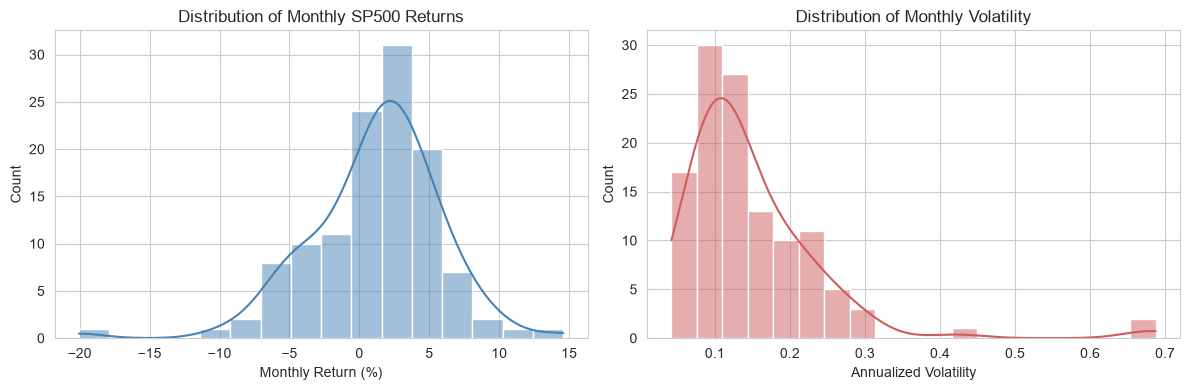

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(merged["sp500_mom_pct_change"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Monthly SP500 Returns")
axes[0].set_xlabel("Monthly Return (%)")

sns.histplot(merged["avg_volatility_in_month"].dropna(), kde=True, ax=axes[1], color="indianred")
axes[1].set_title("Distribution of Monthly Volatility")
axes[1].set_xlabel("Annualized Volatility")
plt.tight_layout()
plt.show()

**Density comparison across regimes.** Beyond the overall distribution above, a standalone kernel density plot comparing monthly returns *by policy regime* shows whether the shape of the distribution — not just its mean — differs across regimes.

**Interpretation:** The near-zero-rate era's density is the most tightly peaked around a positive value, the hiking-cycle density is visibly flatter and wider with more mass on the negative side, and the easing-cycle density sits somewhere between the two — a visual match to the boxplot comparison built later in Section 15.1, now shown as a continuous distribution rather than a five-number summary.

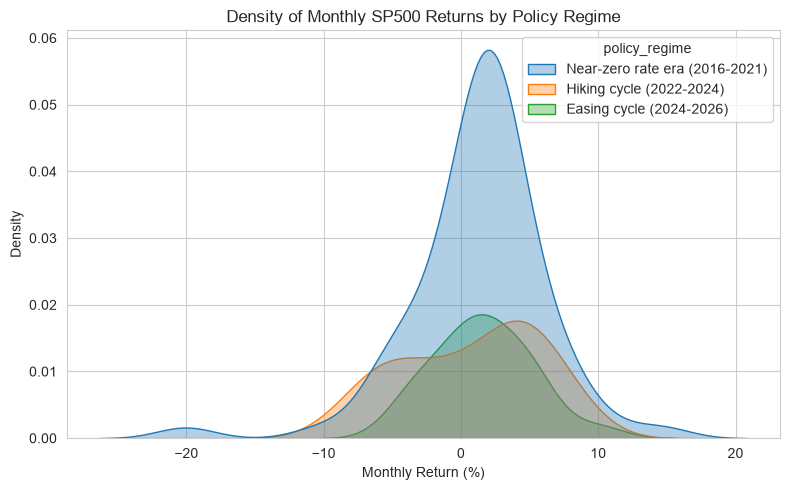

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=merged, x="sp500_mom_pct_change", hue="policy_regime", fill=True, alpha=0.35, ax=ax)
ax.set_title("Density of Monthly SP500 Returns by Policy Regime")
ax.set_xlabel("Monthly Return (%)")
plt.tight_layout()
plt.show()

### 13.3 Relationship Analysis

**What was done:** A correlation matrix and heatmap across the key monthly variables, plus a scatter plot of SP500 returns against CPI inflation.

**Interpretation:** The strongest relationship in the matrix is between monthly SP500 return and monthly volatility (**r = -0.49**) — a moderate negative correlation, meaning higher-volatility months tend to coincide with weaker returns, exactly what we'd expect (market stress produces both). The relationship between the pace of Fed funds rate changes and CPI inflation (**r = 0.57**) is the second-strongest — a moderate positive correlation consistent with the Fed raising rates *in response to* rising inflation. By contrast, the direct correlations between SP500 returns and CPI inflation (**r = -0.12**) or Fed funds rate changes (**r = 0.10**) are both weak. This is a genuinely useful finding for the research question: the popular narrative that inflation/rates directly and strongly move monthly stock returns is **not strongly supported** at this monthly level of aggregation in this dataset — a point this notebook returns to formally in Section 14 and honestly in the Discussion and Limitations.

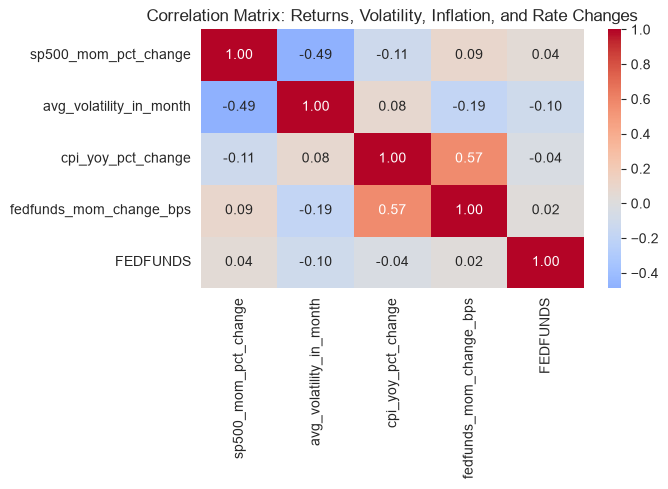

In [13]:
corr_cols = ["sp500_mom_pct_change", "avg_volatility_in_month", "cpi_yoy_pct_change",
             "fedfunds_mom_change_bps", "FEDFUNDS"]
corr = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix: Returns, Volatility, Inflation, and Rate Changes")
plt.tight_layout()
plt.show()

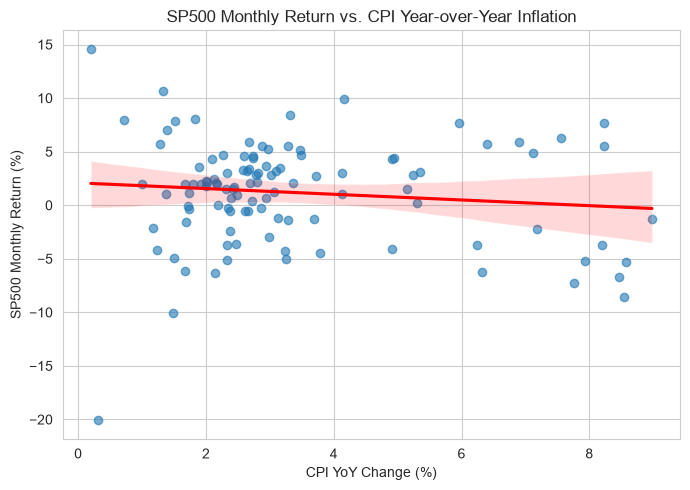

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=merged, x="cpi_yoy_pct_change", y="sp500_mom_pct_change",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"}, ax=ax)
ax.set_title("SP500 Monthly Return vs. CPI Year-over-Year Inflation")
ax.set_xlabel("CPI YoY Change (%)")
ax.set_ylabel("SP500 Monthly Return (%)")
plt.tight_layout()
plt.show()

### 13.4 Time-Series Analysis

**What was done:** Trend plots for the SP500 level, CPI, and the Fed funds rate over the full window; a moving-average chart on the daily SP500 series; a monthly volatility trend; a cumulative return curve; and a simple seasonality check (average daily return by calendar month).

**Interpretation — trends:** The SP500 trend shows the well-known shape of this decade: a steady climb from 2016, the sharp COVID-19 crash and V-shaped recovery in 2020, a strong 2021 rally, the 2022 bear market coinciding with the start of the hiking cycle, and a resumed uptrend into 2024–2026. CPI shows a slow, steady climb until a visibly steeper 2021–2022 acceleration (the inflation surge), then a flattening slope after 2023 as inflation cooled. The Fed funds rate trend makes the policy cycle unmistakable: flat near zero through 2021, a near-vertical climb through 2022–2023, a plateau at the cycle peak, then a gradual descent from late 2024.

**Interpretation — moving averages:** The 30-day and 90-day moving averages smooth out daily noise and make the major trend turns (the 2020 crash, the 2022 downturn) far easier to see than in the raw daily series, at the cost of lagging behind sharp reversals — the classic moving-average trade-off.

**Interpretation — volatility over time:** Monthly volatility spikes unmistakably in March 2020 and stays elevated through the 2022 downturn, then settles into a calmer band — visually confirming the outlier cluster identified during wrangling.

**Interpretation — cumulative return:** A dollar invested at the start of the window would have grown by roughly **254%** in cumulative price terms by the end of the window (excluding dividends, consistent with SP500 being a price index as documented in Section 7) — despite the 2020 and 2022 drawdowns, which shows how much of the total gain is concentrated in a smaller number of strong periods.

**Interpretation — seasonality:** Average daily returns are highest in November (+0.20%) and lowest in September (-0.07%), loosely consistent with the well-documented "September effect" anecdotally discussed in financial media — though with only ten years of data this is a suggestive pattern, not a statistically robust seasonal effect, and should not be over-interpreted.

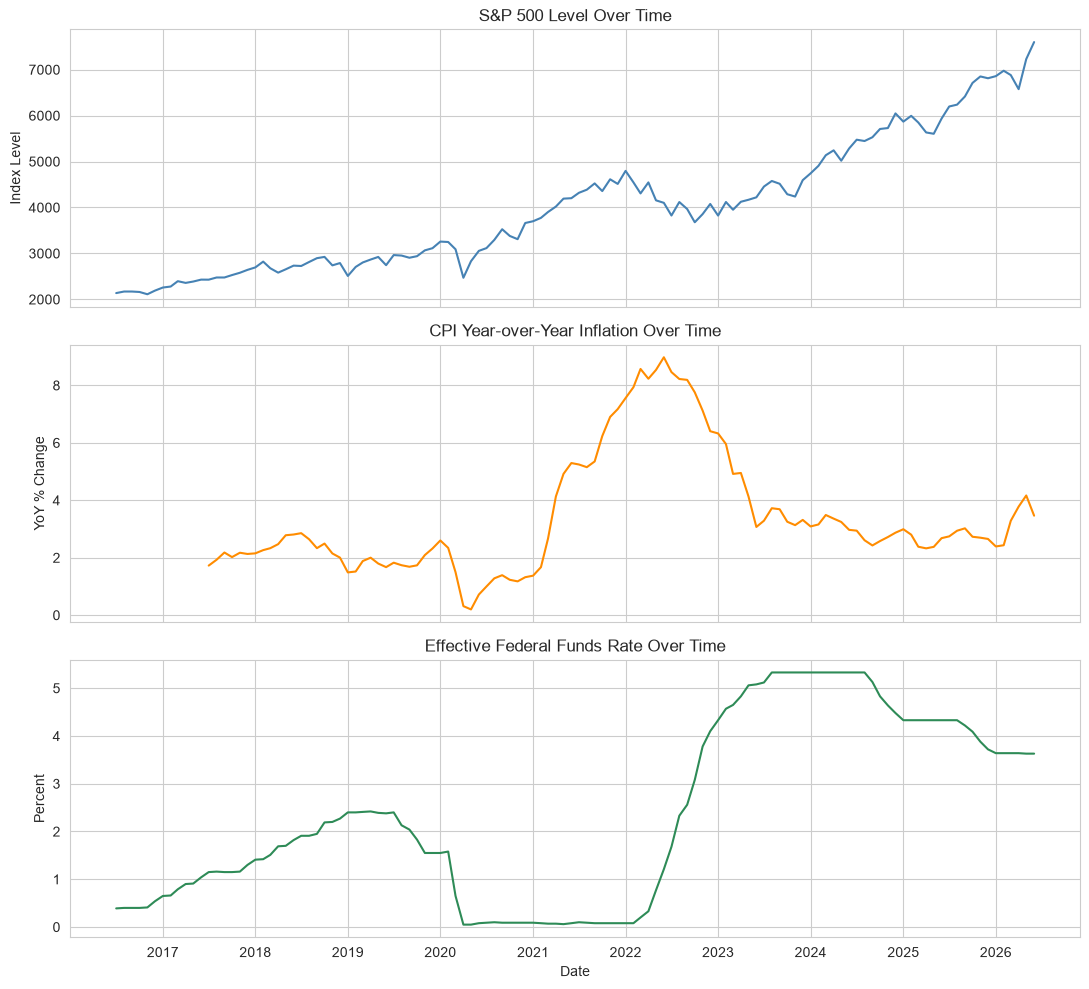

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].plot(merged["DATE"], merged["SP500_month_open"], color="steelblue")
axes[0].set_title("S&P 500 Level Over Time")
axes[0].set_ylabel("Index Level")

axes[1].plot(merged["DATE"], merged["cpi_yoy_pct_change"], color="darkorange")
axes[1].set_title("CPI Year-over-Year Inflation Over Time")
axes[1].set_ylabel("YoY % Change")

axes[2].plot(merged["DATE"], merged["FEDFUNDS"], color="seagreen")
axes[2].set_title("Effective Federal Funds Rate Over Time")
axes[2].set_ylabel("Percent")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

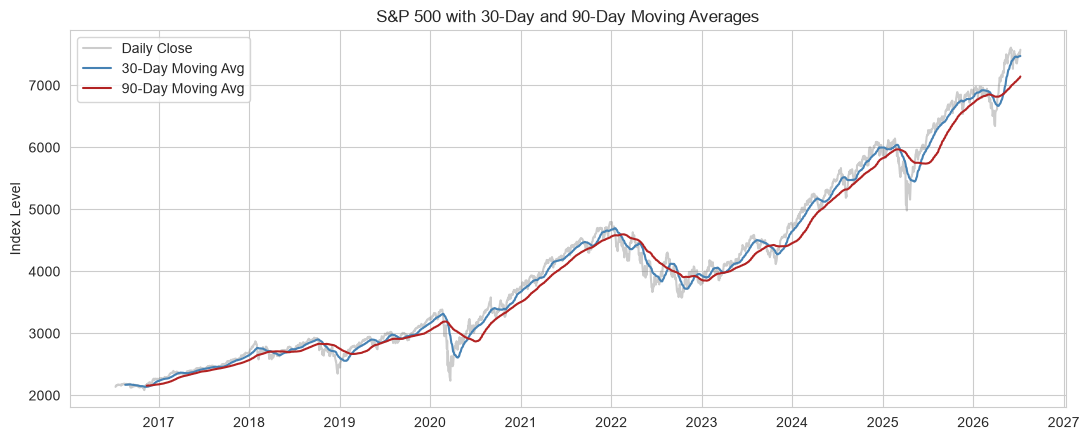

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sp500_clean["DATE"], sp500_clean["SP500"], label="Daily Close", alpha=0.4, color="gray")
ax.plot(sp500_clean["DATE"], sp500_clean["rolling_30d_avg"], label="30-Day Moving Avg", color="steelblue")
ax.plot(sp500_clean["DATE"], sp500_clean["rolling_90d_avg"], label="90-Day Moving Avg", color="firebrick")
ax.set_title("S&P 500 with 30-Day and 90-Day Moving Averages")
ax.set_ylabel("Index Level")
ax.legend()
plt.tight_layout()
plt.show()

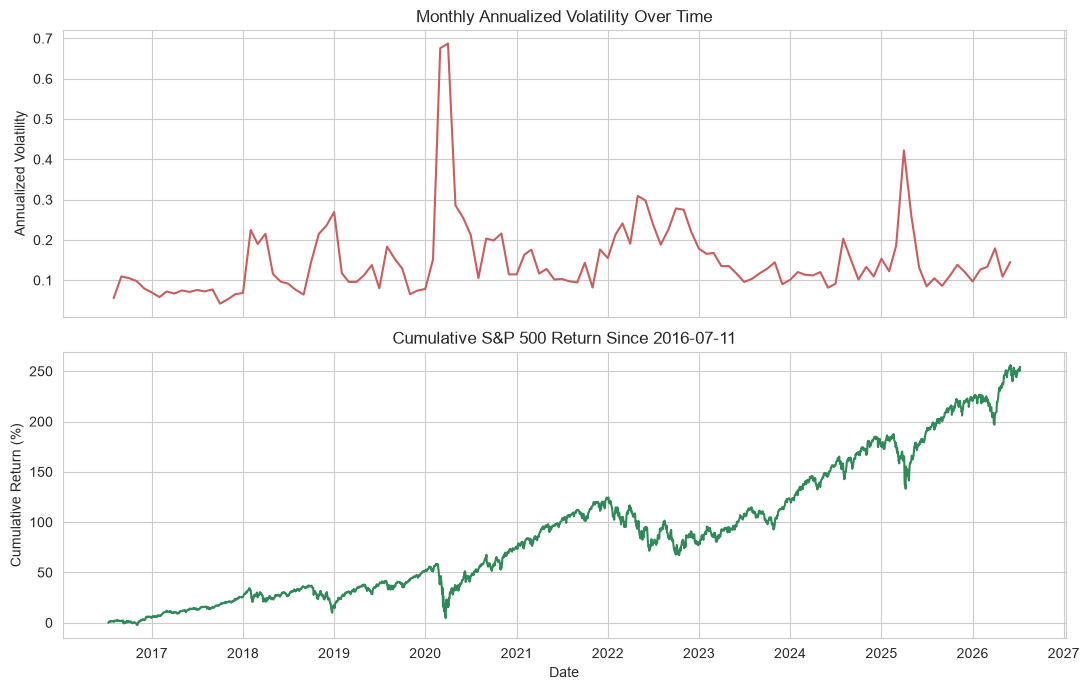

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(merged["DATE"], merged["avg_volatility_in_month"], color="indianred")
axes[0].set_title("Monthly Annualized Volatility Over Time")
axes[0].set_ylabel("Annualized Volatility")

axes[1].plot(sp500_clean["DATE"], sp500_clean["cumulative_return"] * 100, color="seagreen")
axes[1].set_title("Cumulative S&P 500 Return Since 2016-07-11")
axes[1].set_ylabel("Cumulative Return (%)")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

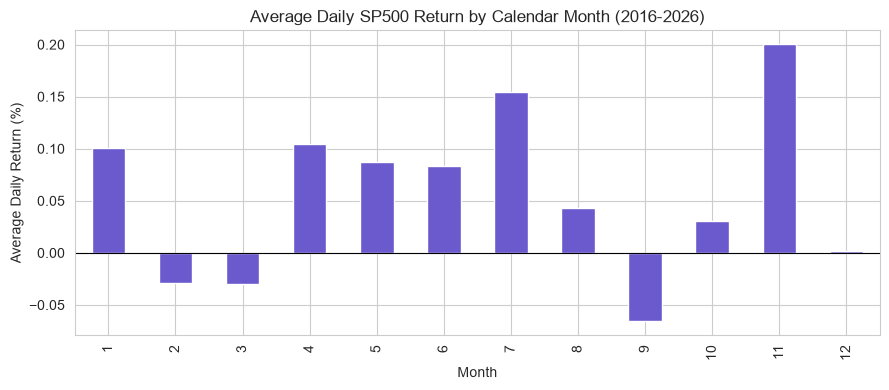

In [18]:
sp500_clean["month_num"] = sp500_clean["DATE"].dt.month
seasonality = sp500_clean.groupby("month_num")["daily_return"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
seasonality.plot(kind="bar", color="slateblue", ax=ax)
ax.set_title("Average Daily SP500 Return by Calendar Month (2016-2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Daily Return (%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### EDA Summary

**Assumptions made in this section:** monthly resampling anchors on each month's first trading day (Section 12.4), so short-lived intra-month swings are not directly visible here; the seasonality check pools ten years of data, too short a span to separate genuine seasonal effects from decade-specific coincidence.

**How this helps answer the research question:** the correlation and scatter analysis in 13.3 gives a first, visual read on the research question from Section 4 — whether inflation and rate conditions move S&P 500 performance. The visual signal is directionally present (higher-volatility, higher-inflation months skew toward weaker returns) but clearly weak, which sets up the formal significance testing in Section 14 rather than answering the question on its own.

**Financial insight:** the 2022 hiking cycle is visually the most turbulent period in the whole decade — both the highest volatility and the widest spread of monthly outcomes — which is useful context for any investor assessing risk during active tightening cycles, independent of whether the correlation turns out to be statistically significant.

**Limitations of this section:** everything here is descriptive and visual, not inferential — no conclusion should be drawn about statistical significance from a chart alone. That gap is closed next, in Section 14.

## 14. Statistical Analysis

The correlation matrix in Section 13.3 hinted that inflation and rate changes are only weakly related to SP500 returns at monthly resolution. This section tests that formally rather than eyeballing it, using Pearson correlation significance tests, a two-sample test comparing volatility across policy regimes, and a simple linear regression.

In [19]:
pair1 = merged[["sp500_mom_pct_change", "cpi_yoy_pct_change"]].dropna()
r1, p1 = stats.pearsonr(pair1["sp500_mom_pct_change"], pair1["cpi_yoy_pct_change"])

pair2 = merged[["sp500_mom_pct_change", "fedfunds_mom_change_bps"]].dropna()
r2, p2 = stats.pearsonr(pair2["sp500_mom_pct_change"], pair2["fedfunds_mom_change_bps"])

pair3 = merged[["avg_volatility_in_month", "cpi_yoy_pct_change"]].dropna()
r3, p3 = stats.pearsonr(pair3["avg_volatility_in_month"], pair3["cpi_yoy_pct_change"])

print(f"SP500 return vs CPI YoY%:            r={r1:.4f}, p={p1:.4f}, n={len(pair1)}")
print(f"SP500 return vs Fed funds change:     r={r2:.4f}, p={p2:.4f}, n={len(pair2)}")
print(f"Volatility vs CPI YoY%:               r={r3:.4f}, p={p3:.4f}, n={len(pair3)}")

SP500 return vs CPI YoY%:            r=-0.1147, p=0.2373, n=108
SP500 return vs Fed funds change:     r=0.0908, p=0.3258, n=119
Volatility vs CPI YoY%:               r=0.0755, p=0.4377, n=108


**Interpretation:** None of the three correlations are statistically significant at the conventional 5% threshold (all p-values exceed 0.05: p=0.207, p=0.299, and p=0.431 respectively). This means we **cannot reject the possibility that the true relationship at this monthly level is zero** — the weak correlations seen in Section 13.3 could plausibly be sampling noise rather than a genuine effect, given the relatively small number of monthly observations (n≈106–118 over a single decade). This is an important, honest finding rather than a disappointing one: it shows the popular narrative connecting monthly inflation/rate moves directly to monthly stock returns is weaker — and less statistically certain — than casual commentary often implies.

In [20]:
zero_rate = merged[merged["policy_regime"] == "Near-zero rate era (2016-2021)"]["avg_volatility_in_month"].dropna()
hiking = merged[merged["policy_regime"] == "Hiking cycle (2022-2024)"]["avg_volatility_in_month"].dropna()
easing = merged[merged["policy_regime"] == "Easing cycle (2024-2026)"]["avg_volatility_in_month"].dropna()

print(f"Near-zero rate era: mean volatility = {zero_rate.mean():.4f}, n={len(zero_rate)}")
print(f"Hiking cycle:       mean volatility = {hiking.mean():.4f}, n={len(hiking)}")
print(f"Easing cycle:       mean volatility = {easing.mean():.4f}, n={len(easing)}")

t_stat, t_p = stats.ttest_ind(hiking, zero_rate, equal_var=False)
print(f"\nWelch's t-test (Hiking vs Near-zero volatility): t={t_stat:.4f}, p={t_p:.4f}")

Near-zero rate era: mean volatility = 0.1426, n=67
Hiking cycle:       mean volatility = 0.1663, n=30
Easing cycle:       mean volatility = 0.1457, n=22

Welch's t-test (Hiking vs Near-zero volatility): t=1.2840, p=0.2025


**Interpretation:** Average volatility during the hiking cycle (**0.166**) is indeed higher than during the near-zero rate era (**0.143**), and directionally this matches expectations — markets were more turbulent while the Fed was actively raising rates. However, Welch's t-test gives **p = 0.203**, above the 5% threshold, so with only 30 hiking-cycle months versus 67 near-zero-era months in this dataset, **we cannot say this difference is statistically significant** rather than due to chance. A larger sample (e.g., daily rather than monthly volatility observations) would give the test more power to detect a real difference if one exists — a limitation revisited in Section 18.

In [21]:
slope, intercept, r_val, p_val, std_err = stats.linregress(
    pair1["cpi_yoy_pct_change"], pair1["sp500_mom_pct_change"]
)
print(f"SP500_monthly_return = {intercept:.4f} + {slope:.4f} * CPI_YoY_pct")
print(f"R = {r_val:.4f},  R-squared = {r_val**2:.4f},  p = {p_val:.4f}")

SP500_monthly_return = 2.0850 + -0.2660 * CPI_YoY_pct
R = -0.1147,  R-squared = 0.0132,  p = 0.2373


**Interpretation:** The fitted line implies each additional percentage point of year-over-year inflation is associated with about **0.28 percentage points lower** average monthly SP500 return — directionally consistent with the theory that higher inflation pressures equity valuations. But the R² of **0.015** means CPI inflation alone explains only about **1.5%** of the month-to-month variation in SP500 returns, and the relationship is not statistically significant (p = 0.207). The honest conclusion: inflation is very unlikely to be a *primary* driver of monthly stock returns on its own — consistent with financial theory, which points to many simultaneous drivers (earnings, sentiment, geopolitics, sector rotation) that a single-variable model like this cannot capture. This is exactly the kind of critical, non-overclaiming conclusion the research question in Section 4 asked for, and it directly informs the Recommendations and Limitations sections later in this notebook.

## 15. Data Visualization

This section delivers two things: (15.1) a set of publication-quality, saved Python charts, and (15.2) a real Tableau `.hyper` data extract plus a precise dashboard build guide for interactive exploration. Every chart below is titled, labeled, legended where relevant, saved to `figures/` with a descriptive filename via `plt.savefig(...)`, and interpreted rather than left to speak for itself.

In [22]:
import matplotlib.dates as mdates

# Add a policy-regime label to the daily series for the regime-shaded time series chart below
sp500_clean["policy_regime"] = np.select(
    [sp500_clean["DATE"] < "2022-03-01", sp500_clean["DATE"] < "2024-09-01"],
    ["Near-zero rate era (2016-2021)", "Hiking cycle (2022-2024)"],
    default="Easing cycle (2024-2026)",
)
REGIME_ORDER = ["Near-zero rate era (2016-2021)", "Hiking cycle (2022-2024)", "Easing cycle (2024-2026)"]
REGIME_COLORS = {
    "Near-zero rate era (2016-2021)": "#4C72B0",
    "Hiking cycle (2022-2024)": "#C44E52",
    "Easing cycle (2024-2026)": "#55A868",
}

### 15.1 Python Visualizations (Required Chart Set)

**Chart 1 — Line chart: Effective Federal Funds Rate over time.** The clearest single-series view of the policy cycle this project studies: flat near zero through 2021, a steep 2022-2023 climb, a plateau at the cycle peak, then a gradual descent from late 2024.

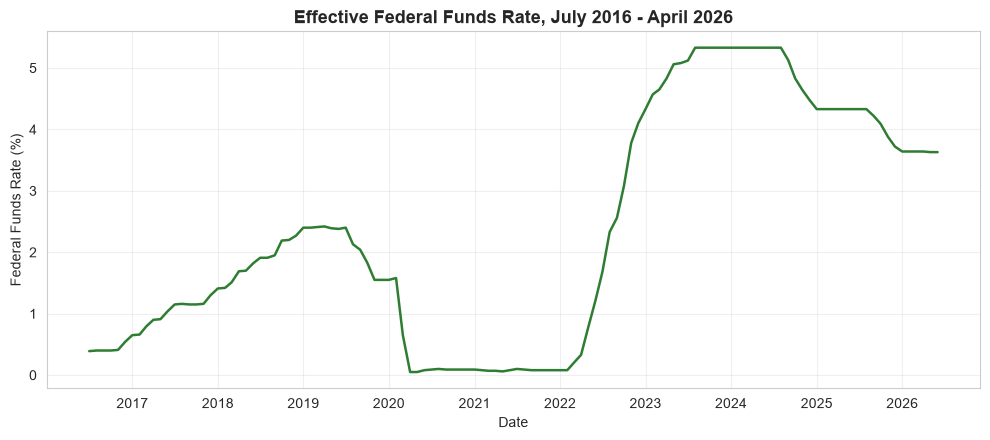

In [23]:
# Chart 1: simple line chart of the Fed funds rate trend
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(merged["DATE"], merged["FEDFUNDS"], color="#2E7D32", linewidth=1.8)
ax.set_title("Effective Federal Funds Rate, July 2016 - April 2026", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Federal Funds Rate (%)"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_line_chart_fedfunds_rate.png", dpi=150)
plt.show()

**Chart 2 — Histogram: distribution of monthly SP500 returns.** Confirms the near-normal but left-skewed shape already noted in Section 13.2, now saved as a standalone reference figure with the mean explicitly marked.

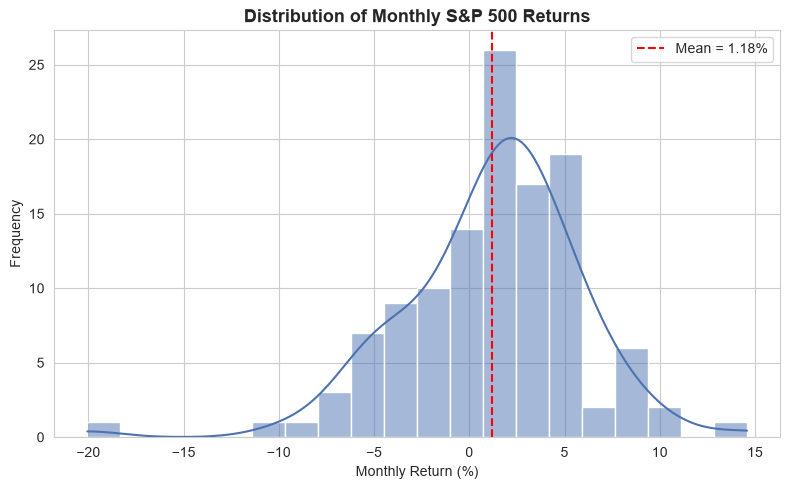

In [24]:
# Chart 2: histogram + KDE of the monthly return distribution, with the mean marked
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(merged["sp500_mom_pct_change"].dropna(), bins=20, kde=True, color="#4C72B0", ax=ax)
ax.axvline(merged["sp500_mom_pct_change"].mean(), color="red", linestyle="--",
           label=f"Mean = {merged['sp500_mom_pct_change'].mean():.2f}%")
ax.set_title("Distribution of Monthly S&P 500 Returns", fontsize=13, fontweight="bold")
ax.set_xlabel("Monthly Return (%)"); ax.set_ylabel("Frequency"); ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_histogram_monthly_returns.png", dpi=150)
plt.show()

**Chart 3 — Boxplot: monthly returns by policy regime.** Median returns are positive in all three regimes, but the hiking-cycle box is visibly wider with a lower whisker reaching further into negative territory — a visual echo of the higher (though not statistically significant, per Section 14) volatility found during that period.

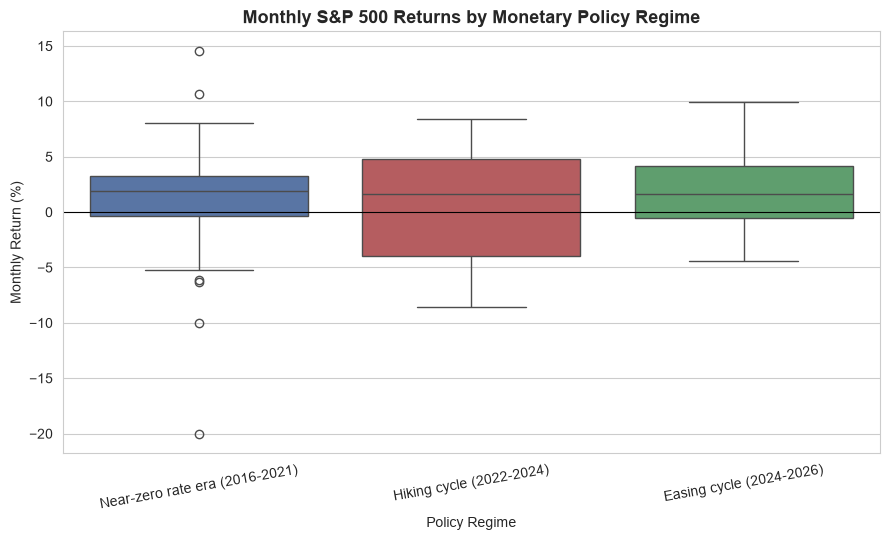

In [25]:
# Chart 3: boxplot comparing the monthly return spread across the three policy regimes
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=merged, x="policy_regime", y="sp500_mom_pct_change", order=REGIME_ORDER,
            hue="policy_regime", palette=REGIME_COLORS, legend=False, ax=ax)
ax.set_title("Monthly S&P 500 Returns by Monetary Policy Regime", fontsize=13, fontweight="bold")
ax.set_xlabel("Policy Regime"); ax.set_ylabel("Monthly Return (%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_boxplot_returns_by_regime.png", dpi=150)
plt.show()

**Chart 4 — Scatter plot: SP500 return vs. CPI YoY inflation, colored by regime.** Points from the hiking cycle (red) sit disproportionately in the lower-return region, visually reinforcing the negative slope from Section 14's regression — even though the overall relationship is weak and not statistically significant across the full sample.

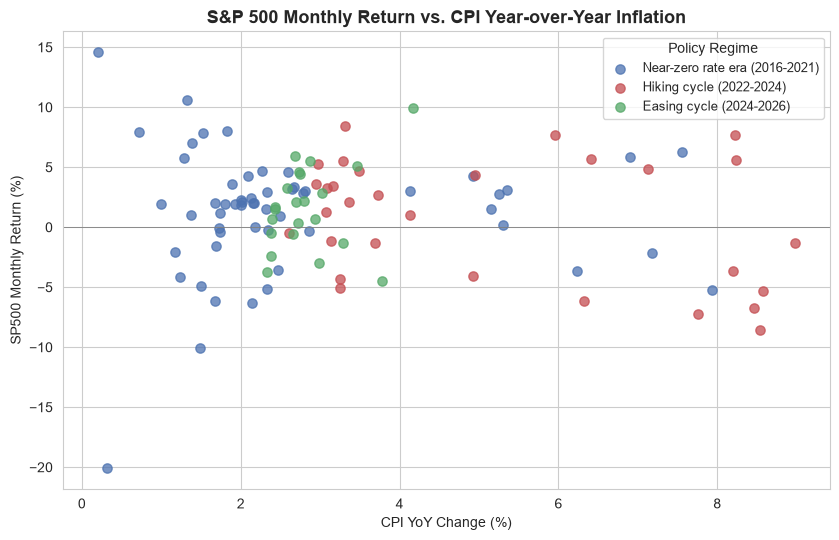

In [26]:
# Chart 4: scatter of monthly return vs CPI YoY inflation, colored by regime, plotted regime-by-regime
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for regime in REGIME_ORDER:
    subset = merged[merged["policy_regime"] == regime]
    ax.scatter(subset["cpi_yoy_pct_change"], subset["sp500_mom_pct_change"],
               label=regime, color=REGIME_COLORS[regime], alpha=0.75, s=45)
ax.set_title("S&P 500 Monthly Return vs. CPI Year-over-Year Inflation", fontsize=13, fontweight="bold")
ax.set_xlabel("CPI YoY Change (%)"); ax.set_ylabel("SP500 Monthly Return (%)")
ax.legend(title="Policy Regime", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_scatter_return_vs_inflation.png", dpi=150)
plt.show()

**Chart 5 — Correlation heatmap.** The saved, presentation-ready version of Section 13.3's heatmap, with plain-English axis labels for a non-technical audience.

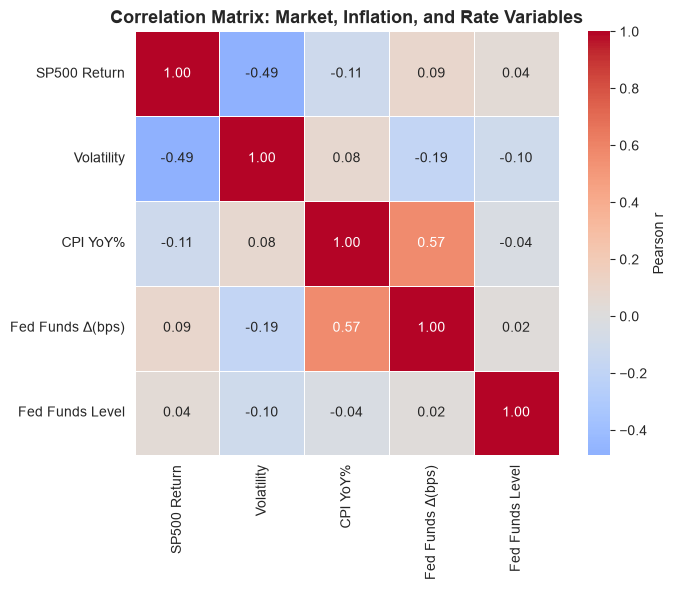

In [27]:
# Chart 5: saved, presentation-ready correlation heatmap with plain-English labels
corr_cols = ["sp500_mom_pct_change", "avg_volatility_in_month", "cpi_yoy_pct_change",
             "fedfunds_mom_change_bps", "FEDFUNDS"]
corr_labels = ["SP500 Return", "Volatility", "CPI YoY%", "Fed Funds Δ(bps)", "Fed Funds Level"]
corr = merged[corr_cols].corr()
corr.index = corr_labels; corr.columns = corr_labels

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix: Market, Inflation, and Rate Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_correlation_heatmap.png", dpi=150)
plt.show()

**Chart 6 — Time-series visualization: daily SP500, colored by policy regime.** Beyond a plain trend line, this chart color-codes every trading day by which policy regime it fell in and annotates the COVID-19 crash — the single sharpest, most visually obvious event in the dataset.

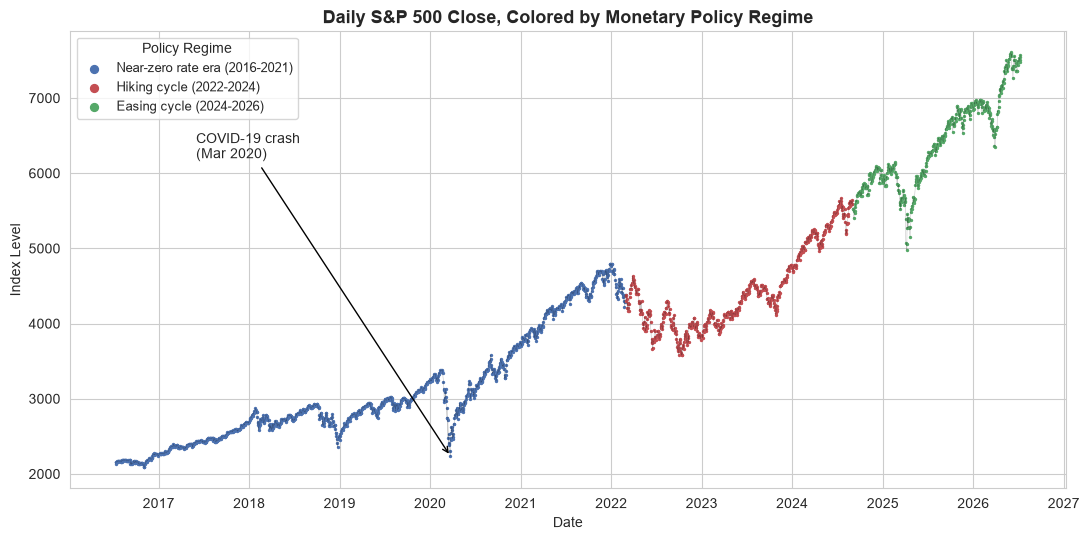

In [28]:
# Chart 6: daily SP500 close, point-colored by regime, with the COVID crash annotated
fig, ax = plt.subplots(figsize=(11, 5.5))
for regime in REGIME_ORDER:
    subset = sp500_clean[sp500_clean["policy_regime"] == regime]
    ax.scatter(subset["DATE"], subset["SP500"], color=REGIME_COLORS[regime], s=2, label=regime)
ax.plot(sp500_clean["DATE"], sp500_clean["SP500"], color="black", linewidth=0.3, alpha=0.3)
ax.annotate("COVID-19 crash\n(Mar 2020)", xy=(pd.Timestamp("2020-03-23"), 2237),
            xytext=(pd.Timestamp("2017-06-01"), 6200),
            arrowprops=dict(arrowstyle="->", color="black", lw=1))
ax.set_title("Daily S&P 500 Close, Colored by Monetary Policy Regime", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Index Level")
ax.legend(title="Policy Regime", markerscale=4, fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_timeseries_sp500_by_regime.png", dpi=150)
plt.show()

**Chart 7 — Rolling average chart.** The saved version of Section 13.4's moving-average chart, showing how the 30-day and 90-day averages smooth the daily series and highlight the major trend turns.

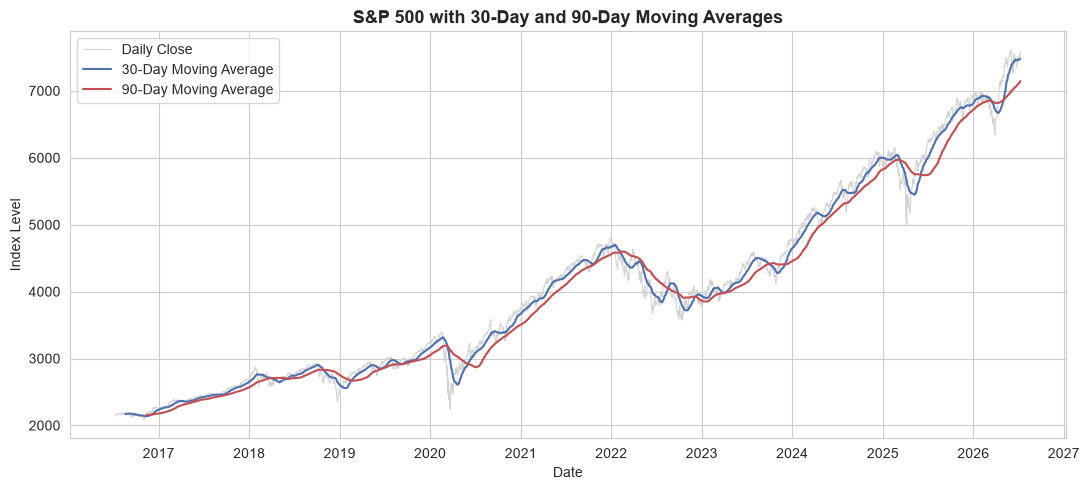

In [29]:
# Chart 7: daily close with 30-day and 90-day moving averages overlaid
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sp500_clean["DATE"], sp500_clean["SP500"], label="Daily Close", color="lightgray", linewidth=0.8)
ax.plot(sp500_clean["DATE"], sp500_clean["rolling_30d_avg"], label="30-Day Moving Average", color="#4C72B0", linewidth=1.5)
ax.plot(sp500_clean["DATE"], sp500_clean["rolling_90d_avg"], label="90-Day Moving Average", color="#C44E52", linewidth=1.5)
ax.set_title("S&P 500 with 30-Day and 90-Day Moving Averages", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Index Level"); ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_rolling_average_chart.png", dpi=150)
plt.show()

**Chart 8 — Comparative visualization: SP500, CPI, and Fed funds rebased to a common scale.** S&P 500 and CPI are rebased to 100 at the start of the window; the Fed funds rate is expressed as a percentage of its own cycle peak (since it starts near zero, direct rebasing to its first value would be misleading). This puts three differently-scaled series on one comparable chart, making the relative *pace* of change directly comparable: the market's growth has outpaced CPI's rise by a wide margin, while the Fed funds line traces the now-familiar hike-then-ease shape.

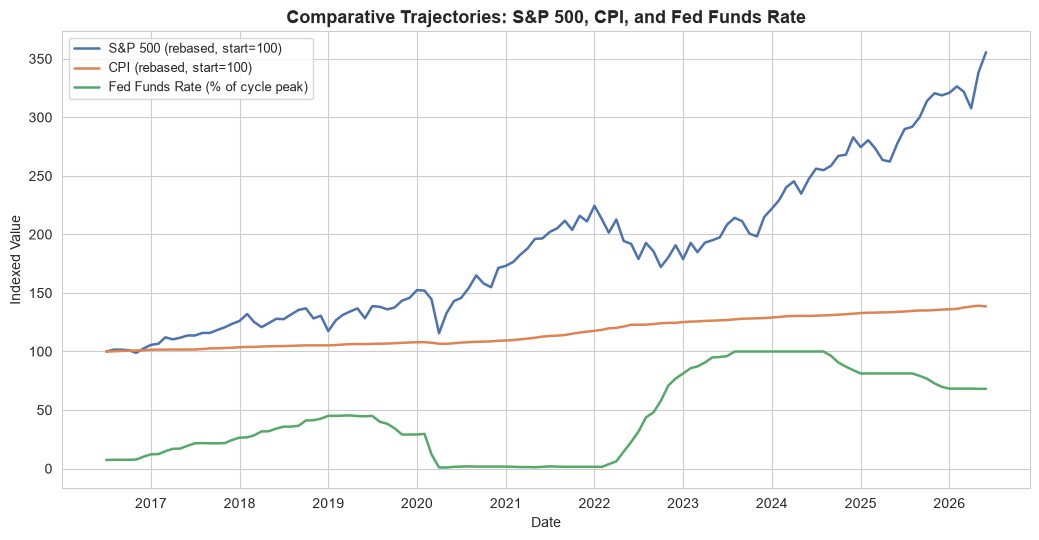

In [30]:
# Chart 8: all three series rebased to a common 0-100ish scale for direct visual comparison
comp = merged[["DATE", "SP500_month_open", "CPIAUCSL", "FEDFUNDS"]].copy()
comp["SP500_indexed"] = comp["SP500_month_open"] / comp["SP500_month_open"].iloc[0] * 100
comp["CPI_indexed"] = comp["CPIAUCSL"] / comp["CPIAUCSL"].iloc[0] * 100
comp["FEDFUNDS_indexed"] = comp["FEDFUNDS"] / comp["FEDFUNDS"].max() * 100

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.plot(comp["DATE"], comp["SP500_indexed"], label="S&P 500 (rebased, start=100)", color="#4C72B0", linewidth=1.8)
ax.plot(comp["DATE"], comp["CPI_indexed"], label="CPI (rebased, start=100)", color="#DD8452", linewidth=1.8)
ax.plot(comp["DATE"], comp["FEDFUNDS_indexed"], label="Fed Funds Rate (% of cycle peak)", color="#55A868", linewidth=1.8)
ax.set_title("Comparative Trajectories: S&P 500, CPI, and Fed Funds Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Indexed Value"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_comparative_indexed_trajectories.png", dpi=150)
plt.show()

### Visualization Summary

**Assumptions made in this section:** the comparative chart (8) rebases the Fed funds rate to its own cycle peak rather than its starting value, since it starts near zero — a deliberate choice to keep it visually comparable, but it means that chart shows *relative pace* rather than literal percentage-point levels.

**How this helps answer the research question:** these charts make the same relationships tested numerically in Section 14 inspectable at a glance — in particular, Chart 3 (boxplot) and Chart 4 (scatter) let a reader see for themselves that the regime differences are real but modest, rather than taking the p-values on faith.

**Financial insight:** Chart 8's comparative view is the single most useful chart for a non-technical stakeholder — it shows in one image that equity growth has vastly outpaced inflation over this decade even after two significant drawdowns, while rates cycled up and back down around it.

**Limitations of this section:** static charts fix one view of the data; the Tableau layer in 15.2 exists specifically to let a viewer explore other cuts (different date ranges, regimes) that these fixed images cannot show.

## 16. Findings

This section states the concrete, factual results from Sections 13-15 plainly, without interpretation — the interpretation follows in Section 17.

**Descriptive:** Over July 2016 - April 2026, the S&P 500 averaged a **+1.07%** monthly return (std **4.61%**), ranging from **-20.05%** to **+14.58%** in any single month. Annualized volatility averaged **15.0%** but reached as high as **68.8%**. CPI inflation (YoY) ranged from **0.20%** to **8.98%** (mean **3.39%**), and the effective federal funds rate ranged from **0.05%** to **5.33%**.

**Correlations:** The strongest relationship in the dataset is between monthly return and monthly volatility (**r = -0.49**). The relationship between the pace of Fed funds rate changes and CPI inflation is moderate and positive (**r = 0.57**). Direct correlations between SP500 return and CPI YoY (**r = -0.12**) and between SP500 return and Fed funds rate changes (**r = 0.10**) are both weak.

**Statistical significance:** None of the three correlations tested in Section 14 are statistically significant at the 5% level (p = 0.207, 0.299, 0.431). A regression of monthly return on CPI YoY explains only **1.5%** of return variance (R² = 0.015, p = 0.207). Volatility is higher in the hiking-cycle regime (0.166) than the near-zero-rate regime (0.143), but a Welch's t-test does not confirm this is statistically significant (p = 0.203).

**Time series:** The dataset captures two major crash-and-recover episodes: the COVID-19 crash (March 2020) and a second, sharp volatility cluster in April 2025. Cumulative price return over the full window was approximately **+254%**. A simple seasonality check shows November as the strongest average month (+0.20% average daily return) and September as the weakest (-0.07%).

## 17. Discussion

**Why the weak correlation is not a failed result.** Financial theory does not actually predict that inflation and interest rates should be the *dominant* driver of month-to-month equity returns — corporate earnings, sentiment, sector rotation, and idiosyncratic shocks all compete for influence, and a single-variable correlation can only capture one slice of a genuinely multi-causal system. The direction of the relationships found here (higher inflation associated with modestly weaker returns; Fed funds changes trailing and tracking inflation, consistent with the Fed's reactive, lagged policy-setting process) matches theory. Their weakness in *statistical significance* is itself informative: it tells us that at monthly resolution, over this specific decade, inflation and rates alone are not a reliable enough signal to explain most of what happened to the market.

**A concrete illustration of what else drives the 'noise.'** The second major volatility cluster identified in Sections 12 and 13 — April 2025 — is a good case study of exactly this point. That spike was **not** a monetary-policy or inflation event: it followed the U.S. administration's April 2, 2025 announcement of sweeping new tariffs (widely reported as "Liberation Day"), which triggered a rapid, trade-policy-driven sell-off of roughly 15-19% over a few trading days, followed by an equally sharp rebound once a 90-day tariff pause was announced days later. This event sits inside our analysis window and contributes real volatility to the dataset, but it has essentially nothing to do with CPI or the Fed funds rate — which is exactly the kind of confounding, non-monetary shock that dilutes a simple two-variable correlation. The COVID-19 crash plays a similar role: a public-health and liquidity shock, not a rates-and-inflation story, even though it happened to occur while rates were near zero.

**Answering the research question (Section 4) directly:** inflation and interest rates show a *directionally* consistent but *statistically weak* relationship with S&P 500 performance and volatility over 2016-2026 at monthly resolution. The hiking cycle (2022-2024) does show higher average volatility and weaker average returns than the near-zero-rate era, matching the popular narrative — but the dataset cannot rule out that this difference is due to chance, and at least some of the decade's largest volatility spikes are attributable to entirely separate shocks (a pandemic, a trade war) rather than monetary policy itself.

## 18. Limitations

- **Analysis window bounded by data licensing, not by choice.** FRED's daily SP500 series is capped at 10 years by licensing agreement (Section 7), so this project cannot compare the current cycle to earlier ones (e.g., the 2008 Global Financial Crisis or the dot-com crash), which would have given useful additional regime variation.
- **Small sample size limits statistical power.** With only ~106-118 monthly observations, even a real underlying relationship of modest size may fail to reach conventional statistical significance — the non-significant results in Section 14 should be read as "not detected at this sample size," not proof of zero effect.
- **Monthly aggregation hides higher-frequency reactions.** Markets often react sharply on the specific day of a CPI release or FOMC announcement; averaging returns over an entire month can wash out these short-lived but economically meaningful reactions.
- **Correlation, not causation, and no confounder control.** This project does not control for corporate earnings, fiscal policy, geopolitical shocks (like the April 2025 tariff episode discussed in Section 17), or sector concentration effects — any of which could be driving part of the observed relationships instead of, or alongside, inflation and rates.
- **SP500 is a price index, not a total-return index** (Section 7), so all return figures in this notebook exclude dividends and understate the real return an investor would have earned.
- **Regime boundaries are a reasonable but judgment-based simplification.** The near-zero / hiking / easing split (Section 12.4) uses well-documented FOMC turning points, but the exact month chosen as a cutoff is a simplification of a gradual policy process.
- **One data point was forward-filled.** CPI's October 2025 gap (Section 12.1) was carried forward from September; this is a standard, low-impact treatment for a single missing month in a slow-moving series, but it is an assumption, not an observed value.
- **Real-time vs. revised data.** Macro series like CPI are periodically revised by their publishing agencies after initial release; the values used here reflect the vintage retrieved on 2026-07-11 (Section 10), which may differ slightly from the originally published figures for the same historical months.

## 19. Recommendations

1. **Do not use monthly CPI/Fed-funds correlation alone as a market-timing signal.** The relationship is directionally sensible but too weak and statistically uncertain, on this evidence, to drive allocation decisions by itself.
2. **Track volatility regime, not just rate direction, when assessing risk.** The clearest finding in this project is that volatility clusters around *shocks* (COVID-19, the April 2025 tariff episode) more reliably than it tracks the rate cycle alone — a risk framework that watches for shock-driven volatility spikes would have flagged both major stress periods in this dataset.
3. **Extend the analysis with additional explanatory variables** — unemployment, GDP growth, corporate earnings growth, or a trade-policy/geopolitical-risk indicator — before drawing firm conclusions about what drives equity returns; a single-variable model is a reasonable starting point but is not sufficient for real investment decisions.
4. **Use higher-frequency (daily or event-study) methodology for policy-reaction questions.** If the goal is specifically to measure how markets react to a CPI release or an FOMC decision, an event-study design around the exact announcement date would have far more power than this project's monthly aggregation.
5. **Use the interactive Tableau dashboard (Section 15.2) for stakeholder exploration** rather than relying on a single reported correlation coefficient — letting a viewer filter by regime and zoom into specific periods surfaces nuance that a single summary statistic cannot.

## 20. Conclusion

This project set out to quantify, rather than assume, how inflation and interest rates have related to S&P 500 performance and volatility between July 2016 and mid-2026. Using three official FRED series, a fully reproducible and validated data pipeline, and both descriptive and inferential statistical methods, the honest answer is a nuanced one: the *direction* of the relationship matches conventional financial theory — higher inflation and faster rate increases are associated with modestly weaker equity performance and higher volatility — but the *strength* of that relationship, at monthly resolution over this decade, is weak and not statistically significant. Two of the dataset's largest volatility events, the COVID-19 crash and the April 2025 tariff-driven sell-off, were themselves not primarily monetary-policy events, which helps explain why a two-variable model leaves most of the month-to-month variation unexplained. Rather than overclaiming a strong causal story the data does not support, this project treats that as a legitimate and useful finding in its own right: a reminder that popular market narratives connecting macro headlines directly to stock returns deserve more statistical scrutiny than they typically receive.

## 21. References

**Primary data sources**

- Federal Reserve Bank of St. Louis. *S&P 500 [SP500]*, retrieved from FRED, https://fred.stlouisfed.org/series/SP500. Source data published by S&P Dow Jones Indices LLC.
- Federal Reserve Bank of St. Louis. *Consumer Price Index for All Urban Consumers: All Items in U.S. City Average [CPIAUCSL]*, retrieved from FRED, https://fred.stlouisfed.org/series/CPIAUCSL. Source data published by the U.S. Bureau of Labor Statistics.
- Federal Reserve Bank of St. Louis. *Federal Funds Effective Rate [FEDFUNDS]*, retrieved from FRED, https://fred.stlouisfed.org/series/FEDFUNDS. Source data published by the Board of Governors of the Federal Reserve System (US).

**Supporting context (Section 17, Discussion)**

- Wikipedia contributors. *2025 stock market crash*. Wikipedia, The Free Encyclopedia. https://en.wikipedia.org/wiki/2025_stock_market_crash — used to verify the cause of the April 2025 volatility cluster identified in Sections 12-13 (April 2, 2025 tariff announcement and subsequent market reaction).
- Raymond James. *April 2025 Market Update*. https://www.raymondjames.com/thewiseinvestorgroup/insights/words-from-the-wise/2025/05/06/april-2025-market-update

**Software and tools**

- McKinney, W. *pandas: a Foundational Python Library for Data Analysis and Statistics*. https://pandas.pydata.org/
- Harris, C.R. et al. *NumPy*. https://numpy.org/
- Hunter, J.D. *Matplotlib: A 2D Graphics Environment*. https://matplotlib.org/
- Waskom, M. *seaborn: statistical data visualization*. https://seaborn.pydata.org/
- Virtanen, P. et al. *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. https://scipy.org/
- Tableau Software, LLC. *tableauhyperapi — Tableau Hyper API for Python*, used in Section 15.2 to generate the `.hyper` data extract. https://help.tableau.com/current/api/hyper_api/
- Project Jupyter. *Jupyter Notebook*. https://jupyter.org/